In [1]:
import copy

import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, ConcatDataset
from neuralop.data.datasets.tensor_dataset import TensorDataset

from conformal_no.data.datasets import SubsampleDataset, make_splits
from conformal_no.training.conformal_fno import load_uqfno

from experiments.expkit.datasets import (load_navier_stokes, load_ns_times, 
                                         load_ns_highres)
from experiments.expkit.paths import CHECKPOINT_DIR
from experiments.expkit.style import set_style
from experiments.expkit.visualise import visualise
from experiments.expkit.plotting import (
    save_figure, plot_resampled_lambda, plot_coverage_histogram, 
    plot_coverage_violins, plot_coarse_fine
)
from experiments.expkit.coverage_resampling import (
    compute_function_scores, compute_ma_function_scores,
    resample_coverage_counts_paired
)
from experiments.expkit.build_results import build_results

from configs import (RESOLUTIONS, CONFIGS, SPLIT_SIZES, SEED, MODEL_VERSION,
                     N_CAL_RESAMPLE, N_RESAMPLES, INPUT_TIME, OUTPUT_TIME)


In [13]:
set_style()

EXPERIMENT_NAME = "ns"
RESULTS_PATH = Path("results") / "results_df.pkl"

# Set True to re-run the experiments (slow). False loads cached results.
RECOMPUTE = False

device = torch.device("cpu")

In [3]:
raw = load_navier_stokes(input_time=INPUT_TIME, output_time=OUTPUT_TIME)
predictor_dataset, error_dataset, calibration_dataset = make_splits(
    raw["train"], SPLIT_SIZES, seed=SEED
)
test_dataset = TensorDataset(*raw["test"])

In [4]:
loaders = {
    res: {
        "calib": DataLoader(SubsampleDataset(calibration_dataset, res),
                            batch_size=CONFIGS[res]["batch_size"], shuffle=False),
        "test": DataLoader(SubsampleDataset(test_dataset, res),
                           batch_size=CONFIGS[res]["batch_size"], shuffle=False),
    }
    for res in RESOLUTIONS
}

In [5]:
CALIBRATION_METHODS = {
    "Ours": lambda m, loader, cfg: m.conformal_calibrate(loader, alpha=cfg["alpha"]),
    "Ma et al.": lambda m, loader, cfg: m.ma_conformal_calibrate(loader, alpha=cfg["alpha"]),
}

models = {}
for res in RESOLUTIONS:
    fitted = load_uqfno(
        CONFIGS[res],
        CHECKPOINT_DIR / f"{EXPERIMENT_NAME}_uqfno_{res}_v{MODEL_VERSION}.pt",
        device,
    )
    for method in CALIBRATION_METHODS:
        models[(method, res)] = copy.deepcopy(fitted)

for (method, res), model in models.items():
    CALIBRATION_METHODS[method](model, loaders[res]["calib"], CONFIGS[res])

In [14]:
if RECOMPUTE:
    combined_dataset = ConcatDataset([test_dataset, calibration_dataset])
    combined_loaders = {
        res: DataLoader(SubsampleDataset(combined_dataset, res),
                        batch_size=CONFIGS[res]["batch_size"], shuffle=False)
        for res in RESOLUTIONS
    }

    # High-resolution test set, on a different time grid to the training file,
    # so the times are matched by physical value rather than index.
    FINE = 256
    t_train = load_ns_times()
    x_fine, y_fine = load_ns_highres(t_in=t_train[INPUT_TIME],
                                     t_out=t_train[OUTPUT_TIME])
    fine_dataset = TensorDataset(x=x_fine, y=y_fine)

    interp_loaders = {
        res: DataLoader(SubsampleDataset(fine_dataset, res, output_resolution=FINE),
                        batch_size=CONFIGS[res]["batch_size"], shuffle=False)
        for res in RESOLUTIONS
    }
    finest_loader = DataLoader(SubsampleDataset(fine_dataset, FINE),
                               batch_size=4, shuffle=False)

    results_df = build_results(
        models, loaders, combined_loaders, interp_loaders, finest_loader,
        CONFIGS, RESOLUTIONS,
        n_cal_resample=N_CAL_RESAMPLE, n_resamples=N_RESAMPLES, seed=SEED,
    )
    RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    results_df.to_pickle(RESULTS_PATH)
else:
    results_df = pd.read_pickle(RESULTS_PATH)

results_df

,method,resolution,mean bandwidth,scale factor,coverage counts,resampled lambda,coverage zero-shot,coverage interpolated
0,Ma et al.,16,0.746886,3.423517,"[1500, 1500, 1500, 1500, 1500, 1500, 1500, 150...","[3.3646199703216553, 3.3633952140808105, 3.338...",1.00,1.00
1,Ma et al.,32,0.471549,2.343879,"[1488, 1489, 1491, 1495, 1495, 1491, 1495, 149...","[2.2943482398986816, 2.3484785556793213, 2.358...",1.00,1.00
2,Ma et al.,64,0.435819,2.111690,"[1487, 1487, 1487, 1484, 1486, 1482, 1485, 148...","[2.1252739429473877, 2.157630443572998, 2.1452...",1.00,1.00
3,Ours,16,0.418767,1.919513,"[1354, 1317, 1316, 1359, 1333, 1317, 1341, 130...","[1.927017092704773, 1.8905560970306396, 1.8903...",0.80,0.00
4,Ours,32,0.354477,1.761963,"[1327, 1349, 1376, 1384, 1320, 1367, 1379, 133...","[1.7452707290649414, 1.7691354751586914, 1.791...",0.95,0.95
5,Ours,64,0.354077,1.715623,"[1355, 1335, 1354, 1344, 1365, 1318, 1354, 134...","[1.7341976165771484, 1.715623378753662, 1.7336...",0.90,0.90


True solution RMS: 1.6269505023956299
True error RMS: 0.1898052841424942
Predicted solution RMS: 1.6049944162368774
Predicted error RMS: 0.3731691539287567


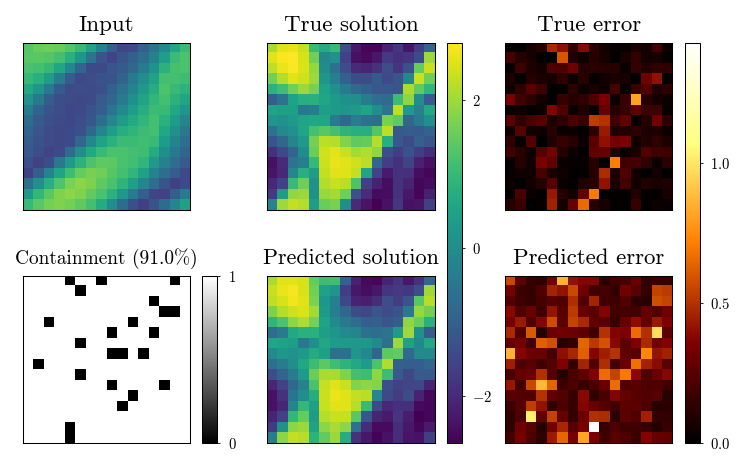

In [65]:
res = 16
fig = visualise(
    loaders[res]["test"], models[("Ours", res)]
)

In [66]:
save_figure(fig, f"coarse_visualisation_{EXPERIMENT_NAME}", EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/ns/coarse_visualisation_ns.pdf


True solution RMS: 1.638964295387268
True error RMS: 0.15329797565937042
Predicted solution RMS: 1.6580811738967896
Predicted error RMS: 0.3339395821094513


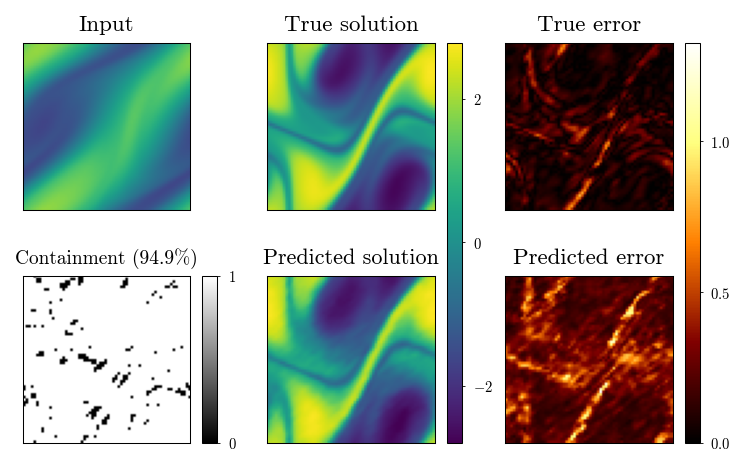

In [71]:
res = 64
fig = visualise(
    loaders[res]["test"], models[("Ours", res)]
)

In [72]:
save_figure(fig, f"fine_visualisation_{EXPERIMENT_NAME}", subdir=EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/ns/fine_visualisation_ns.pdf


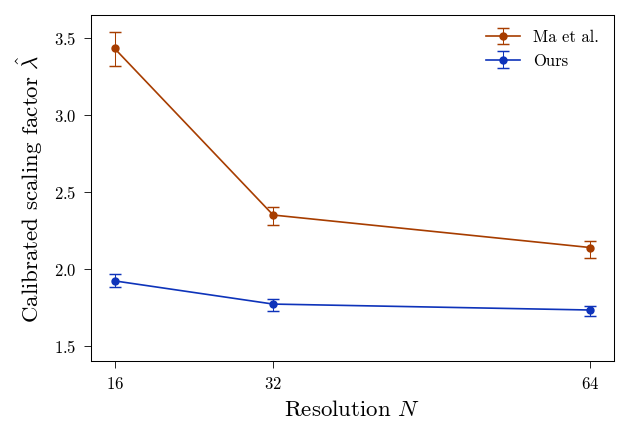

In [9]:
fig = plot_resampled_lambda(results_df, ylim=(1.4, 3.65), yticks=[1.5, 2, 2.5, 3, 3.5])

In [49]:
save_figure(fig, f"resampled_lambda_{EXPERIMENT_NAME}", EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/ns/resampled_lambda_ns.pdf


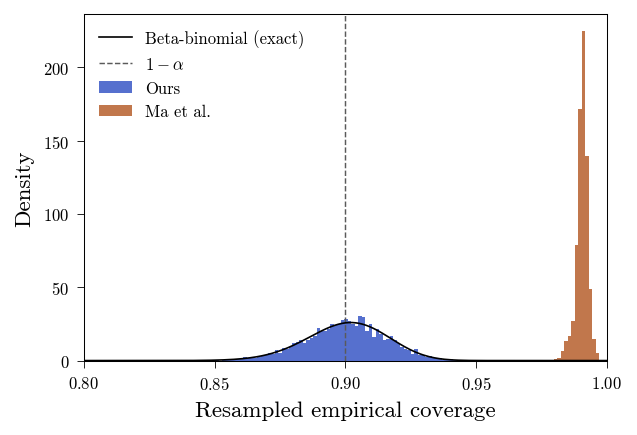

In [10]:
n_test = len(test_dataset) + len(calibration_dataset) - N_CAL_RESAMPLE
alpha = CONFIGS[RESOLUTIONS[0]]["alpha"]

fig = plot_coverage_histogram(results_df, resolution=64, n_cal=N_CAL_RESAMPLE, 
                              n_test=n_test, alpha=alpha, bin_width=2, 
                              xticks=[0.80, 0.85, 0.9, 0.95, 1])

In [74]:
save_figure(fig, f"coverage_histogram_{EXPERIMENT_NAME}", EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/ns/coverage_histogram_ns.pdf


In [39]:
import importlib
import experiments.expkit.plotting as p
importlib.reload(p)
from experiments.expkit.plotting import plot_coverage_violins

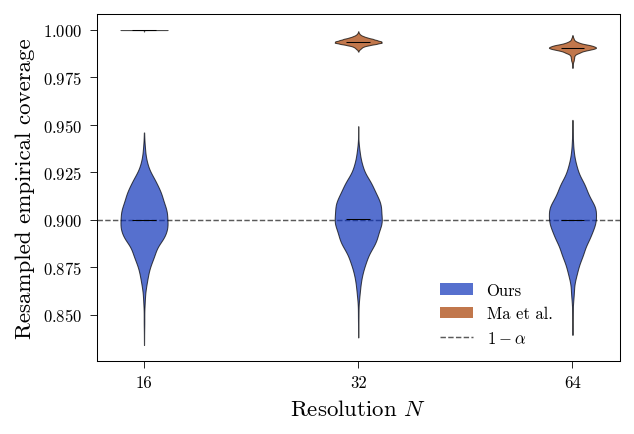

In [11]:
fig = plot_coverage_violins(results_df, n_test=n_test, alpha=alpha, 
                            legend_shift=0.1)

In [42]:
save_figure(fig, f"violins_{EXPERIMENT_NAME}", EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/ns/violins_ns.pdf


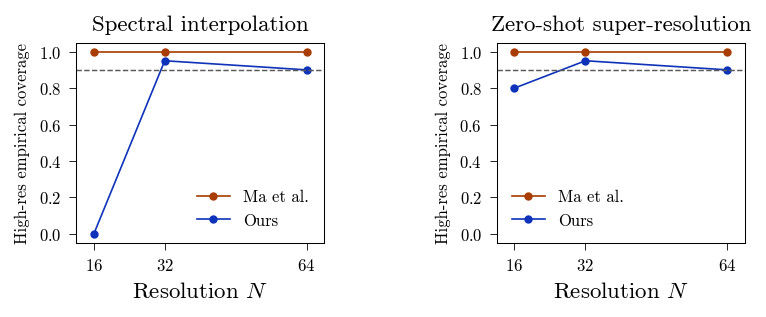

In [12]:
fig = plot_coarse_fine(results_df, alpha=alpha, xlim=(12, 68))

In [46]:
save_figure(fig, f"coarse_fine_{EXPERIMENT_NAME}", EXPERIMENT_NAME)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved report/figures/ns/coarse_fine_ns.pdf
